In [326]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [327]:
df=pd.read_csv("/content/banking_transactions (1).csv")

In [328]:
df.head()


,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


In [329]:
df.tail()


,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
9995,1009996,3552.90,1,36.6,21,0.16,1315,21,12,17919.66,117,14829,36,75.4,Mobile App,Password Only,0,0,1,False
9996,1009997,21559.69,11,14.4,28,0.26,4644,22,11,8477.85,15,10795,63,10.8,POS Terminal,Two-Factor Authentication,0,1,1,False
9997,1009998,4181.33,1,84.0,50,0.23,262,3,3,272564.27,60,3840,91,93.3,Mobile App,Biometric,0,1,1,False
9998,1009999,21443.71,3,33.8,44,0.01,255,4,14,142791.28,116,10110,42,87.1,Mobile App,OTP,1,1,1,False
9999,1010000,24974.25,12,0.0,4,0.87,532,1,19,367234.24,104,7202,102,14.9,POS Terminal,Biometric,0,1,1,True


In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes        1

In [331]:
df.describe()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.005000e+06,12412.754004,6.438900,50.257190,39.648400,0.348916,2510.240900,11.553600,12.437800,249367.527976,60.614300,7604.567500,60.479300,50.122240,0.492800,0.498400,0.500500
std,2.886896e+03,7200.700863,3.453558,29.414463,23.419868,0.236890,1436.335019,6.962254,7.532875,144580.006647,34.821533,4330.728784,34.833419,29.271512,0.499973,0.500022,0.500025
min,1.000001e+06,6.270000,1.000000,0.000000,0.000000,0.010000,6.000000,0.000000,0.000000,104.160000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.002501e+06,6174.025000,3.000000,25.100000,19.000000,0.170000,1271.750000,6.000000,6.000000,122291.355000,30.750000,3896.000000,30.000000,24.800000,0.000000,0.000000,0.000000
50%,1.005000e+06,12322.965000,6.000000,50.200000,40.000000,0.310000,2511.000000,11.000000,13.000000,249799.800000,60.000000,7645.000000,61.000000,50.150000,0.000000,0.000000,1.000000
75%,1.007500e+06,18619.650000,9.000000,75.500000,60.000000,0.480000,3746.250000,18.000000,19.000000,373146.842500,91.000000,11376.250000,91.000000,75.400000,1.000000,1.000000,1.000000
max,1.010000e+06,24997.520000,12.000000,100.000000,80.000000,0.990000,5000.000000,23.000000,25.000000,499968.250000,120.000000,14997.000000,120.000000,100.000000,1.000000,1.000000,1.000000


In [332]:
df.isna().sum()

,0
transaction_id,0
transaction_amount,0
login_attempts,0
device_risk_score,0
transfer_frequency,0
anomaly_score,0
account_age_days,0
transaction_time_hour,0
failed_transactions_last_30d,0
avg_monthly_balance,0


In [333]:
df.columns

Index(['transaction_id', 'transaction_amount', 'login_attempts',
       'device_risk_score', 'transfer_frequency', 'anomaly_score',
       'account_age_days', 'transaction_time_hour',
       'failed_transactions_last_30d', 'avg_monthly_balance',
       'daily_transaction_count', 'geo_distance_km',
       'session_duration_minutes', 'transaction_velocity_score',
       'payment_channel', 'authentication_type', 'card_present_flag',
       'international_transaction_flag', 'suspicious_ip_flag', 'fraud_flag'],
      dtype='object')

In [334]:
df.duplicated().sum()

np.int64(0)

In [335]:
df['fraud_flag'].unique()

array([False,  True])

In [336]:
df['anomaly_score'].value_counts()

,count
anomaly_score,
0.01,713
0.27,212
0.29,197
0.28,197
0.32,196
...,...
0.94,17
0.91,17
0.96,16


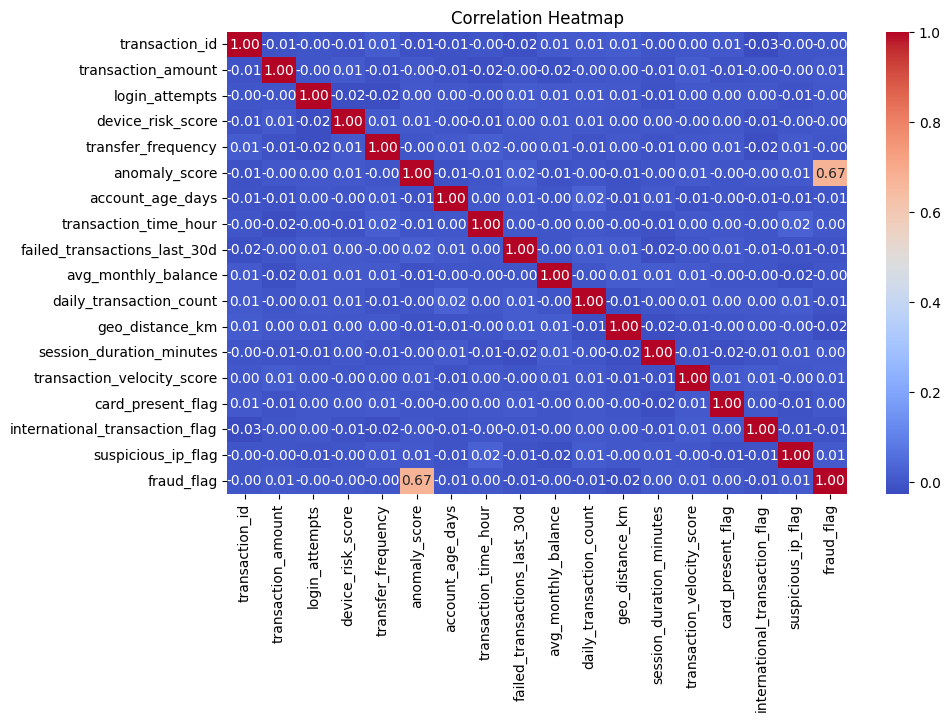

In [337]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot =True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

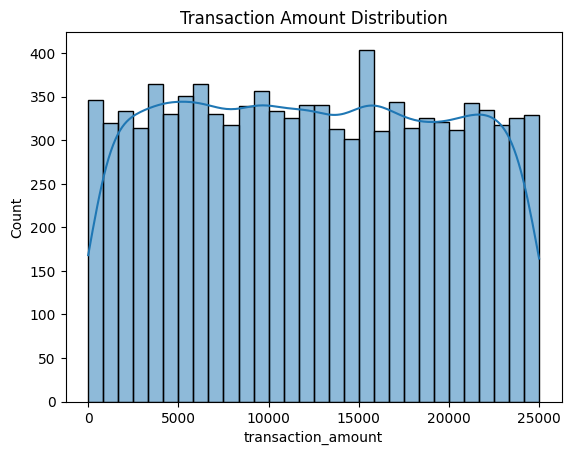

In [338]:
sns.histplot(df["transaction_amount"], bins=30, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

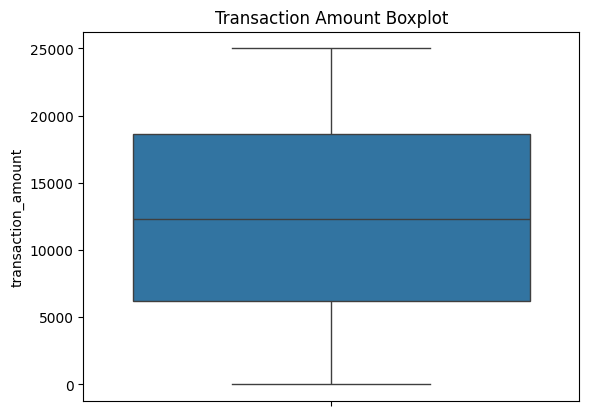

In [339]:
sns.boxplot(y=df["transaction_amount"])

plt.title("Transaction Amount Boxplot")
plt.show()

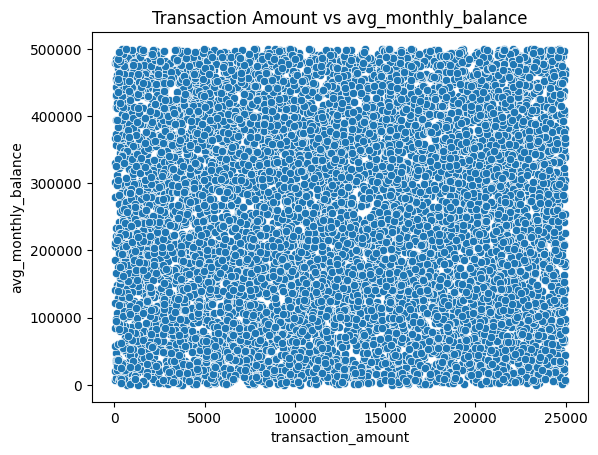

In [340]:
sns.scatterplot(x="transaction_amount", y="avg_monthly_balance", data=df)
plt.title("Transaction Amount vs avg_monthly_balance")
plt.show()

In [341]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes        1

In [342]:
# Feature Engineering

In [343]:
df["balance_usage_ratio"] = (
    df["transaction_amount"] / (df["avg_monthly_balance"] + 1)
)

In [344]:
df["security_risk_score"] = (
    df["login_attempts"] +
    df["failed_transactions_last_30d"] +
    df["suspicious_ip_flag"]
)

In [345]:
df["international_high_amount"] = (
    df["international_transaction_flag"] *
    df["transaction_amount"]
)

In [346]:
df["behavior_risk_score"] = (
    df["device_risk_score"] +
    df["anomaly_score"] +
    df["transaction_velocity_score"]
)

In [347]:
df["geo_risk"] = (
    df["geo_distance_km"] *
    df["transaction_velocity_score"]
)

In [348]:
df["frequency_risk"] = (
    df["daily_transaction_count"] *
    df["transaction_velocity_score"]
)

In [349]:
df["fraud_score"] = (
      0.25 * df["behavior_risk_score"]
    + 0.20 * df["security_risk_score"]
    + 0.20 * df["geo_risk"]
    + 0.15 * df["frequency_risk"]
    + 0.20 * df["balance_usage_ratio"]
)

In [350]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes        1

In [351]:
print(df["payment_channel"].unique())
print(df["authentication_type"].unique())

['POS Terminal' 'Web Banking' 'ATM' 'Mobile App']
['OTP' 'Biometric' 'Two-Factor Authentication' 'Password Only']


In [352]:
from sklearn.preprocessing import LabelEncoder
df = pd.get_dummies(
    df,
    columns=["payment_channel", "authentication_type"],
    drop_first=True
)

In [353]:
# df.info()

In [354]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   transaction_id                                 10000 non-null  int64  
 1   transaction_amount                             10000 non-null  float64
 2   login_attempts                                 10000 non-null  int64  
 3   device_risk_score                              10000 non-null  float64
 4   transfer_frequency                             10000 non-null  int64  
 5   anomaly_score                                  10000 non-null  float64
 6   account_age_days                               10000 non-null  int64  
 7   transaction_time_hour                          10000 non-null  int64  
 8   failed_transactions_last_30d                   10000 non-null  int64  
 9   avg_monthly_balance                            1000

In [356]:
x = df.drop("fraud_flag", axis=1)
y = df["fraud_flag"]

In [357]:
from sklearn.preprocessing import StandardScaler
x_scaler = StandardScaler()
x_scaled = x_scaler.fit_transform(x)

In [358]:
# Handle Imbalanced Data
from imblearn.over_sampling import SMOTE
print("\nBefore SMOTE:")
print(y.value_counts())
smote = SMOTE(random_state=42)
x_scaled, y = smote.fit_resample(x_scaled, y)
print("\nAfter SMOTE:")
print(pd.Series(y).value_counts())


Before SMOTE:
fraud_flag
0    8749
1    1251
Name: count, dtype: int64

After SMOTE:
fraud_flag
0    8749
1    8749
Name: count, dtype: int64


In [359]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [360]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score,roc_curve

In [361]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=50,max_depth=5,random_state=42),
    "XGBoost": XGBClassifier(  n_estimators=50,learning_rate=0.05,max_depth=8,
    subsample=0.9,colsample_bytree=0.9,random_state=42,eval_metric='logloss')
}


In [374]:
result_df = pd.DataFrame(result, columns=["Model", "Accuracy", "ROC AUC"])
best_model_row = result_df.loc[result_df['ROC AUC'].idxmax()]
best_model_name = best_model_row['Model']
best_score = best_model_row['ROC AUC']

best_model = models[best_model_name]

print("Best Model is :", best_model_name)
print("Best ROC AUC Score is :", best_score)

Best Model is : XGBoost
Best ROC AUC Score is : 0.9901776853391225


In [375]:
result =[]
for name,model in models.items():
    print(f"{name}")
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    y_prob = model.predict_proba(X_test)
    roc_auc = roc_auc_score(y_test, y_prob[:, 1])
    result.append([name, accuracy, roc_auc])

Logistic Regression
Random Forest
XGBoost


In [368]:
y_prob = model.predict_proba(X_test)
print(y_prob)

[[0.95505005 0.04494993]
 [0.9536735  0.04632654]
 [0.95565957 0.04434043]
 ...
 [0.22275096 0.77724904]
 [0.12301213 0.8769879 ]
 [0.05892944 0.94107056]]


In [369]:
conf_matrix = confusion_matrix(y_test,y_pred)
print(conf_matrix)

[[1677   90]
 [  39 1694]]


In [370]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1767
           1       0.95      0.98      0.96      1733

    accuracy                           0.96      3500
   macro avg       0.96      0.96      0.96      3500
weighted avg       0.96      0.96      0.96      3500



In [371]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9631428571428572


In [376]:
import joblib
joblib.dump(best_model, "best_fraud_model.pkl")

print("Best Model :", best_model_name)
print("Best ROC-AUC :", best_score)

Best Model : XGBoost
Best ROC-AUC : 0.9901776853391225


In [377]:
# Save every model
joblib.dump(model, f"{name}.pkl")

['XGBoost.pkl']